# Notebook 00 - Course Setup: Python, Jupyter in VS Code, and GitHub

**Paññāsāstra University of Cambodia**
**Course:** Data Analysis and Visualization (3 credits)
**Preliminary session - to be completed before Week 1**

---

## Purpose of this notebook

Every later notebook in this course assumes three things: a working Python interpreter, a
Jupyter kernel running inside VS Code, and a GitHub repository holding your work. This
notebook establishes all three, in that order.

It is written to be executed as you read it. The code cells check that each step of the
installation actually worked, rather than asking you to assume that it did.

## One toolchain, one path

This course uses a single setup. Do not substitute parts of it, because the troubleshooting
guidance at the end assumes this configuration.

| Component | Choice | Purpose |
|---|---|---|
| Interpreter | Python 3 from `python.org` | Runs your code |
| Environment | `venv` in the course folder | Keeps this course's packages separate |
| Editor | Visual Studio Code | Where you write and run notebooks |
| Notebook interface | VS Code **Jupyter extension** | Renders and executes `.ipynb` files |
| Kernel | `ipykernel` inside your `venv` | The process that executes your code |
| Version control | `git` and GitHub | Submission and history |

If you already have Anaconda or Miniconda installed, it will not interfere, but this course
does not use `conda` commands. Follow the instructions exactly as given.

## Reading

| Topic | Source |
|---|---|
| Installation and development environments | McKinney, *Python for Data Analysis* (3rd ed.), §1.4 |
| Essential library ecosystem | McKinney, §1.3 |
| Jupyter notebook basics | McKinney, §2.2 |
| Virtual environments, `pip` | Pfaffelhuber, *Python for Data Analysis*, §11.6 |
| Reading tracebacks, debugging | Pfaffelhuber, §11.7 |
| `git` and GitHub | Pfaffelhuber, §11.8 |
| Comments, `==`, dot-notation, `assert` | Pfaffelhuber, §11.1–11.5 |

## Learning outcomes

On completing this notebook you will be able to:

1. Install Python and confirm the installation from a terminal.
2. Create and activate a virtual environment, and install packages into it.
3. Install the Jupyter extension in VS Code and bind a notebook to a chosen kernel.
4. Explain what a kernel is and diagnose the errors caused by selecting the wrong one.
5. Distinguish Markdown cells from code cells, and control notebook execution order.
6. Read a Python traceback and locate the line that raised the error.
7. Initialise a `git` repository, commit work, and push it to GitHub.

---

## Using AI (ChatGPT, Gemini etc, Copilot, Claude, etc)

During the last years, AI has increasingly improved in code writing. You are encouraged to use this new technology! As usual when learning new things, this new tool can help a lot, and will be able to solve the exercises within the Jupyter notebooks. However, you still have to undestand the code, and what might go wrong during execution. As a first course in Python, you will end up having up to a few hundred lines of code, which has to be coherent. You must know the structure of that code, and in order to extend it, fix bugs etc. If you are ever involved in bigger projects, this is even more important. For these course notes, I have also used AI (ChatGPT, Gemini, Claude Opus) in order to ask the AI which topics I should cover, and make concrete suggestions for a workflow.

## Part 1 - Theory: what you are installing, and why

### 1.1 The four layers of the toolchain

Students often treat "installing Python" as one action. It is four separate layers, and
most setup problems come from confusing them.

```
   INTERPRETER    python.exe          the program that runs code
        |
   ENVIRONMENT    venv/               a folder with its own copy + its own packages
        |
   PACKAGES       numpy, pandas       libraries installed INTO an environment
        |
   EDITOR         VS Code + Jupyter   where you type
```

| Layer | What it is | In this course |
|---|---|---|
| **Interpreter** | The program that executes Python code | `python.exe` from python.org |
| **Environment** | A folder holding one interpreter and its own packages | `venv/` inside your course folder |
| **Packages** | Libraries installed into an environment | `numpy`, `pandas`, `matplotlib`, … |
| **Editor / interface** | The program you type in | VS Code with the Jupyter extension |

A single machine may hold several interpreters and many environments. When an import fails
with `ModuleNotFoundError` even though you are certain you installed the package, the cause
is almost always that the package went into one environment while your notebook is running
in another.

### 1.2 Why a virtual environment is not optional

Different projects require different, sometimes incompatible, versions of the same library.
Installing everything into the system interpreter means that upgrading a package for one
project can silently break another. A virtual environment is a directory holding its own
interpreter and its own `site-packages`, so each project's dependencies are independent
(Pfaffelhuber, §11.6).

The cost is one command at the start of a project. The benefit is that your Week 13 case
study still runs in Week 15.

### 1.3 How Jupyter works inside VS Code

This section explains the mechanism, because understanding it is what lets you fix the most
common error in the course by yourself.

**A notebook is a file.** An `.ipynb` file is a JSON document containing an ordered list of
cells. It stores the source of each cell and, optionally, the output that cell produced last
time it ran. The file itself does not run anything.

**A kernel is a process.** When you execute a cell, the code is sent to a separate operating
system process called a *kernel*. The kernel holds all your variables in memory, executes
the code, and sends results back. For Python, that kernel is provided by the `ipykernel`
package.

**The extension connects the two.** The VS Code Jupyter extension renders the notebook,
sends cell source to the kernel, and displays what comes back.

```
    You type in a cell
           |
           v
   VS Code Jupyter extension  ------>  kernel process (ipykernel)
   (renders the .ipynb file)   <------  (holds variables, runs code)
                                          |
                                          +-- reads packages from ONE environment
```

Three consequences follow, and each explains a class of error:

1. **The kernel determines which packages you have.** The extension does not import
   anything. If your kernel is the system Python and you installed `pandas` into your
   `venv`, the import fails. The remedy is to select the correct kernel, not to reinstall
   the package.
2. **The kernel holds state between cells.** A variable defined in cell 5 still exists when
   you run cell 2. This is why a notebook can appear to work while being broken for anyone
   who runs it from top to bottom.
3. **Restarting the kernel discards all variables.** This is the correct response to
   confusing behaviour, and it is how you prove your notebook runs from a clean start.

**Why this course does not install the `jupyter` package.** The classic Jupyter Notebook and
JupyterLab are browser-based *servers*, distributed as the `jupyter`, `notebook` and
`jupyterlab` packages. The VS Code Jupyter extension replaces that browser interface: it
provides the editing surface itself and talks to the kernel directly. The only thing it
needs inside your environment is `ipykernel`. Installing the full `jupyter` package as well
is harmless but unnecessary, and it is a common source of confusion when two interfaces
compete for the same kernel.

### 1.4 The library ecosystem

McKinney (§1.3) describes the packages this course depends on. Their division of labour
matters, because knowing which library owns a problem is half of solving it.

| Library | Responsibility in this course | First used |
|---|---|---|
| **NumPy** | The `ndarray`: homogeneous, n-dimensional numeric arrays; vectorised arithmetic | Week 3 |
| **pandas** | `Series` and `DataFrame`: labelled, heterogeneous tabular data; alignment, missing data, joins | Week 4 |
| **matplotlib** | The underlying plotting engine; figures, axes, full control of every visual element | Week 7 |
| **seaborn** | Statistical graphics built on matplotlib; concise syntax for distributions and categories | Week 8 |
| **SciPy** | Scientific routines; this course uses `scipy.stats` for distributions and tests | Week 12 |
| **Plotly** | Interactive, browser-rendered charts and dashboards | Week 11 |
| **ipykernel** | The kernel process that executes your notebook cells | Every week |
| **openpyxl** | Lets pandas read and write `.xlsx` files | Week 4 |

pandas is built on NumPy, and seaborn is built on matplotlib and pandas. Installing the
higher-level package therefore pulls in the lower-level ones.

---

## Part 2 - Installation

Work through §2.1 to §2.7 in order. Each step depends on the one before it.

### 2.1 Install Python

**Windows**

1. Download the latest stable Python 3 installer from `https://www.python.org/downloads/`.
2. Run the installer. On the first screen, **tick "Add python.exe to PATH"** before clicking
   *Install Now*. This is the single most common Windows setup error; skipping it is what
   produces `'python' is not recognized as an internal or external command`.
3. Open a **new** PowerShell window (an existing one will not see the updated PATH) and
   check both commands:

```powershell
python --version
pip --version
```

Both should print a version number. If `python` opens the Microsoft Store instead, PATH was
not set: re-run the installer, choose *Modify*, and tick the PATH option.

**macOS**

macOS ships with a system Python that should not be used for project work.

```bash
brew install python
python3 --version
pip3 --version
```

If you do not have Homebrew, download the macOS installer from `https://www.python.org/downloads/`
instead.

**Linux (Debian / Ubuntu)**

```bash
sudo apt update
sudo apt install python3 python3-pip python3-venv
python3 --version
```

### 2.2 Install VS Code

Download from `https://code.visualstudio.com/` and install with the default options.

On Windows, accept the option to *Add "Open with Code" action to the Windows Explorer
directory context menu*. It saves time later.

### 2.3 Install the Jupyter extension in VS Code

This is the step that gives VS Code the ability to open and run notebooks.

1. Open VS Code.
2. Open the Extensions view: click the square-blocks icon in the left sidebar, or press
   `Ctrl+Shift+X` (`Cmd+Shift+X` on macOS).
3. In the search box, type **Python**. Install the extension published by **Microsoft**.
   Confirm the publisher, because there are similarly named extensions from other authors.
4. Search for **Jupyter**. Install the extension published by **Microsoft**.

The Jupyter extension installs several companions automatically: *Jupyter Keymap*,
*Jupyter Notebook Renderers*, *Jupyter Cell Tags* and *Jupyter Slide Show*. Leave them
enabled.

To confirm both installed, type `@installed` in the Extensions search box. *Python* and
*Jupyter* should both be listed under **Installed**.

> An alternative to steps 2–4: press `Ctrl+P`, then paste `ext install ms-python.python`
> and press Enter; repeat with `ext install ms-toolsai.jupyter`.

### 2.4 Create the course folder and open it in VS Code

Create the folder `PUC_PythonForData` in your user directory if it does not already exist.

Then in VS Code: **File → Open Folder…** and select `PUC_PythonForData`.

Open the *folder*, never a single file. VS Code resolves your environment, your relative
file paths and your `git` repository from the folder it has open. Opening a lone `.ipynb`
file is the cause of a large share of "it worked yesterday" problems.

### 2.5 Create the virtual environment

Open the integrated terminal inside VS Code with **Ctrl+`** (the backtick key, above Tab).
It opens already positioned in your course folder.

**Windows (PowerShell):**

```powershell
python -m venv venv
venv\Scripts\activate
```

**macOS / Linux:**

```bash
python3 -m venv venv
source venv/bin/activate
```

When the environment is active, the prompt is prefixed with `(venv)`. Confirm that the
active interpreter is the one inside the environment:

```powershell
where python       # Windows  -> should end in ...\PUC_PythonForData\venv\Scripts\python.exe
```

```bash
which python       # macOS / Linux -> should end in .../PUC_PythonForData/venv/bin/python
```

If the path shown is not inside `venv`, the activation did not take effect. On Windows this
is usually the PowerShell execution policy; see the troubleshooting table at the end.

To leave the environment later, run `deactivate`.

### 2.6 Install the packages

With `(venv)` visible in your prompt:

```bash
pip install --upgrade pip
pip install numpy pandas matplotlib seaborn scipy plotly ipykernel openpyxl
pip freeze > requirements.txt
```

Note what is **not** in that list: `jupyter`, `notebook` and `jupyterlab`. As explained in
§1.3, the VS Code Jupyter extension supplies the interface, and `ipykernel` supplies the
kernel. Nothing else is required.

`requirements.txt` records the exact versions installed. A classmate can reproduce your
environment with `pip install -r requirements.txt`, which is why this file is committed to
`git` while the `venv/` folder is not.

### 2.7 Select the kernel

This is the step that connects the notebook to the environment you just built.

1. Open this notebook in VS Code (**File → Open File…**, then select
   `00_setup_python_jupyter_vscode_github.ipynb`).
2. Look at the **top-right corner** of the notebook. It shows either **Select Kernel** or
   the name of a currently selected kernel.
3. Click it. In the picker that appears, choose **Python Environments…**.
4. Select the entry whose path contains `venv` - it is usually labelled
   `venv (Python 3.x.x)` and marked *Recommended*.

If no environments appear, or the picker reports that `ipykernel` is missing, confirm that
§2.6 completed inside the activated environment, then run **Developer: Reload Window** from
the Command Palette (`Ctrl+Shift+P`).

You can also set the default interpreter for the whole folder: `Ctrl+Shift+P` →
**Python: Select Interpreter** → choose the `venv` entry.

### 2.8 Working with cells

A notebook is an ordered list of cells. Each is either a **code cell**, executed by the
kernel, or a **Markdown cell**, rendered as formatted text.

| Action | Shortcut |
|---|---|
| Run cell, stay in place | `Ctrl+Enter` |
| Run cell, move to next | `Shift+Enter` |
| Run cell, insert new below | `Alt+Enter` |
| Insert cell above / below | `A` / `B` (command mode) |
| Change cell to Markdown / code | `M` / `Y` (command mode) |
| Delete cell | `D`, `D` (command mode) |
| Enter command mode | `Esc` |
| Enter edit mode | `Enter` |
| Restart kernel | Command Palette → *Jupyter: Restart Kernel* |
| Run all cells | The **Run All** button in the notebook toolbar |

**Execution order matters.** The number beside a code cell, `[3]`, is its *execution count*,
not its position. A notebook that runs correctly for you may fail for your instructor if you
executed the cells out of order.

Before submitting any notebook in this course, use **Restart Kernel and Run All Cells** from
the notebook toolbar, and confirm it completes without error. This requirement applies to
every assignment.

---

## Part 3 - Verifying the installation

Run the four cells below in order. The first is the most important: it reports which
interpreter your kernel is actually using, which is the fact that explains almost every
setup problem.

In [1]:
# Cell 1 of 4 — which interpreter is this kernel running?
import sys
import platform
from pathlib import Path

executable = Path(sys.executable)

print("Python version :", sys.version.split()[0])
print("Executable     :", executable)
print("Platform       :", platform.system(), platform.release())
print("Working dir    :", Path.cwd())

# sys.prefix is the active environment; sys.base_prefix is the interpreter it was built
# from. They differ exactly when a virtual environment is in use.
in_venv = sys.base_prefix != sys.prefix
print("\nEnvironment root :", sys.prefix)
print("Base interpreter :", sys.base_prefix)
print("Running inside a virtual environment:", in_venv)

if in_venv and "venv" in str(executable):
    print("\nCorrect: the kernel is running from your course virtual environment.")
elif in_venv:
    print("\nA virtual environment is active, but its name is not 'venv'.")
    print("If you named it something else, this is fine.")
else:
    print("\nWARNING: this kernel is NOT running inside a virtual environment.")
    print("Packages you installed into venv will not be importable.")
    print("Fix: click the kernel name in the top-right corner of this notebook")
    print("     and select the entry whose path contains 'venv'.")

Python version : 3.12.0
Executable     : c:\Users\63601\OneDrive\Desktop\PUC\venv\Scripts\python.exe
Platform       : Windows 11
Working dir    : c:\Users\63601\OneDrive\Desktop\PUC

Environment root : c:\Users\63601\OneDrive\Desktop\PUC\venv
Base interpreter : C:\Users\63601\AppData\Local\Programs\Python\Python312
Running inside a virtual environment: True

Correct: the kernel is running from your course virtual environment.


In [2]:
# Cell 2 of 4 — package availability and versions
import importlib

REQUIRED = ["numpy", "pandas", "matplotlib", "seaborn", "scipy"]
OPTIONAL = ["plotly", "openpyxl", "ipykernel"]


def check_packages(names):
    """Import each package and report its version, without stopping on failure.

    Parameters
    ----------
    names : list of str
        Package names to import.

    Returns
    -------
    dict
        Maps package name -> version string, or None if the import failed.
    """
    results = {}
    for name in names:
        try:
            module = importlib.import_module(name)
            results[name] = getattr(module, "__version__", "unknown")
        except ImportError:
            results[name] = None
    return results


required_status = check_packages(REQUIRED)
optional_status = check_packages(OPTIONAL)

print("REQUIRED PACKAGES")
for name, version in required_status.items():
    mark = "OK     " if version else "MISSING"
    print(f"  [{mark}] {name:<12} {version or '-- run: pip install ' + name}")

print("\nSUPPORTING PACKAGES")
for name, version in optional_status.items():
    mark = "OK     " if version else "missing"
    print(f"  [{mark}] {name:<12} {version or '-- run: pip install ' + name}")

missing_required = [n for n, v in required_status.items() if v is None]
if missing_required:
    print(f"\nInstall these first: {', '.join(missing_required)}")
    print("If you believe they ARE installed, the kernel is pointing at the wrong")
    print("environment. Re-read the output of Cell 1.")
else:
    print("\nSummary: environment ready.")

REQUIRED PACKAGES
  [OK     ] numpy        2.5.3
  [OK     ] pandas       3.0.6
  [OK     ] matplotlib   3.11.2
  [OK     ] seaborn      0.13.2
  [OK     ] scipy        1.18.1

SUPPORTING PACKAGES
  [OK     ] plotly       7.1.0
  [OK     ] openpyxl     3.1.5
  [OK     ] ipykernel    7.3.0

Summary: environment ready.


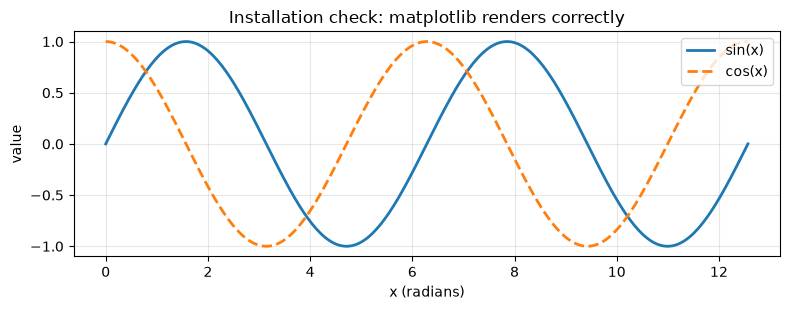

If a figure with two curves appears above, plotting is configured correctly.
The Jupyter extension displays figures inline; no extra configuration is needed.


In [3]:
# Cell 3 of 4 — confirm the plotting backend renders inside VS Code
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4 * np.pi, 300)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(x, np.sin(x), label="sin(x)", linewidth=2)
ax.plot(x, np.cos(x), label="cos(x)", linewidth=2, linestyle="--")
ax.set_title("Installation check: matplotlib renders correctly")
ax.set_xlabel("x (radians)")
ax.set_ylabel("value")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("If a figure with two curves appears above, plotting is configured correctly.")
print("The Jupyter extension displays figures inline; no extra configuration is needed.")

In [4]:
# Cell 4 of 4 — confirm pandas can build, save and reload a table
import pandas as pd

df = pd.DataFrame({
    "student_id": [1001, 1002, 1003, 1004],
    "name": ["Sophea", "Dara", "Chanthou", "Rithy"],
    "score": [78.5, 91.0, 66.25, 84.0],
    "passed": [True, True, True, True],
})

print("DataFrame created:")
print(df)
print("\nColumn data types:")
print(df.dtypes)

# Round-trip through CSV to confirm read/write permissions in this folder.
df.to_csv("setup_check.csv", index=False)
reloaded = pd.read_csv("setup_check.csv")
print("\nCSV round-trip successful:", reloaded.shape == df.shape)
print("File was written to:", Path.cwd() / "setup_check.csv")

# Remove the temporary file.
Path("setup_check.csv").unlink()
print("Temporary file removed. pandas is working correctly.")

DataFrame created:
   student_id      name  score  passed
0        1001    Sophea  78.50    True
1        1002      Dara  91.00    True
2        1003  Chanthou  66.25    True
3        1004     Rithy  84.00    True

Column data types:
student_id      int64
name              str
score         float64
passed           bool
dtype: object

CSV round-trip successful: True
File was written to: c:\Users\63601\OneDrive\Desktop\PUC\setup_check.csv
Temporary file removed. pandas is working correctly.


### Proving the notebook runs from a clean start

Now demonstrate the submission requirement on this notebook.

1. In the notebook toolbar, click **Restart** (the circular arrow), then **Run All**. On most
   versions the single button **Restart Kernel and Run All Cells** does both.
2. Watch the execution counts. After a restart they begin again at `[1]` and increase by one
   down the notebook.
3. Confirm that no cell shows an error, except the deliberate examples in Part 5 and the
   `TODO` cells in Parts 7 and 8, which you have not completed yet.

If a cell fails after a restart but worked before, it depended on a variable defined by a
cell you had run earlier and have since changed or deleted. This is exactly the failure the
restart is designed to expose.

---

## Part 4 - Python conventions used throughout this course

These are small points, but they appear in every later notebook (Pfaffelhuber, §11.1–11.5).

### 4.1 Comments

`#` begins a comment; the rest of the line is ignored by the interpreter.

### 4.2 One equals sign versus two

`x = 0` is **assignment**: it binds the name `x` to the value `0`.
`x == 0` is a **comparison**: it evaluates to `True` or `False`.

Use `==` to compare values. Use `is` only to test identity against `None`, as in
`if x is None:`. Confusing the two is a frequent source of silent logic errors.

### 4.3 Dot-notation

For a function `str.upper(s)` where `s` is a string, you may equivalently write `s.upper()`.
The object before the dot is passed as the first argument. This is why `df.head()` and
`series.mean()` read the way they do.

### 4.4 Type hints and assertions

Python does not enforce types, but annotating them improves readability:

```python
def square(x: float) -> float:
    """Return x squared."""
    return x * x
```

The `assert` statement raises `AssertionError` when its condition is false. Homework in this
course is validated with `assert` blocks, so that you can check your own work before
submitting it.

In [5]:
# Demonstration of the conventions described above.

def describe_value(x: float) -> str:
    """Return a short description of a numeric value.

    Parameters
    ----------
    x : float
        The value to describe.

    Returns
    -------
    str
        One of 'negative', 'zero' or 'positive'.
    """
    if x < 0:
        return "negative"
    elif x == 0:          # two equals signs: comparison, not assignment
        return "zero"
    else:
        return "positive"


for value in [-4.2, 0, 7]:
    print(f"{value:>6} -> {describe_value(value)}")

# Dot-notation: these two calls are equivalent.
text = "  Data Analysis  "
print("\nstr.strip(text) :", repr(str.strip(text)))
print("text.strip()    :", repr(text.strip()))

# Assertions: silent when true, AssertionError when false.
assert describe_value(-1) == "negative"
assert describe_value(0) == "zero"
assert describe_value(1) == "positive"
print("\nAll assertions passed.")

  -4.2 -> negative
     0 -> zero
     7 -> positive

str.strip(text) : 'Data Analysis'
text.strip()    : 'Data Analysis'

All assertions passed.


---

## Part 5 - Reading error messages

When Python raises an error it prints a **traceback**: a record of the call stack at the
moment the error occurred. Learning to read it is a core skill (Pfaffelhuber, §11.7).

**Read a traceback from the bottom upwards.**

1. The **last line** gives the error type and a short description, for example
   `ZeroDivisionError: division by zero`.
2. The lines above it show the **call stack**: which function called which, in which file, at
   which line number. The most recent call is at the bottom.
3. The line of code responsible is shown beneath each location.

The cell below raises an error deliberately, catches it, and prints the traceback so you can
practise reading one. The notebook continues to run afterwards.

In [8]:
import traceback


def divide(a: float, b: float) -> float:
    """Divide a by b."""
    return a / b


def run_calculation() -> float:
    """Call divide with a denominator of zero, to produce a traceback."""
    return divide(10, 0)


try:
    run_calculation()
except ZeroDivisionError:
    print("A traceback was produced. Read it from the bottom upwards:\n")
    traceback.print_exc()
    print("\nBottom line    : ZeroDivisionError - the error type and description.")
    print("Line above it  : the call to 'a / b' inside divide(), where it happened.")
    print("Line above that: the call to divide() inside run_calculation(), which led there.")

A traceback was produced. Read it from the bottom upwards:


Bottom line    : ZeroDivisionError - the error type and description.
Line above it  : the call to 'a / b' inside divide(), where it happened.
Line above that: the call to divide() inside run_calculation(), which led there.


Traceback (most recent call last):
  File "C:\Users\63601\AppData\Local\Temp\ipykernel_9520\2015839516.py", line 15, in <module>
    run_calculation()
  File "C:\Users\63601\AppData\Local\Temp\ipykernel_9520\2015839516.py", line 11, in run_calculation
    return divide(10, 0)
           ^^^^^^^^^^^^^
  File "C:\Users\63601\AppData\Local\Temp\ipykernel_9520\2015839516.py", line 6, in divide
    return a / b
           ~~^~~
ZeroDivisionError: division by zero


### Common error types

| Error | Usual cause |
|---|---|
| `ModuleNotFoundError` | Package not installed, **or the wrong kernel is selected** |
| `NameError` | Variable used before assignment, often a cell run out of order |
| `FileNotFoundError` | Wrong relative path; check the working directory |
| `KeyError` | Column or dictionary key does not exist; check spelling and case |
| `TypeError` | Operation applied to an incompatible type, e.g. adding `str` and `int` |
| `ValueError` | Correct type but unacceptable value, e.g. `int("abc")` |
| `IndentationError` | Inconsistent indentation; use four spaces throughout |

`ModuleNotFoundError` deserves the emphasis. Before running `pip install` again, re-run Cell
1 of Part 3 and read which interpreter the kernel is using. In this course the cause is more
often the kernel than the package.

### Debugging with `print`

When the error message alone is not sufficient, inspect values directly. The f-string `=`
form prints both the variable name and its value, which is convenient when checking several
variables at once.

In [9]:
# The f-string '=' specifier prints the expression and its value together.
rows = 120
columns = 8
cell_count = rows * columns

print(f"{rows = }")
print(f"{columns = }")
print(f"{cell_count = }")

# type() answers the second most common debugging question.
value = "42"
print(f"\n{value = }, {type(value) = }")
print("Adding a string to an integer would raise TypeError; convert first:")
print(f"int(value) + 1 = {int(value) + 1}")

rows = 120
columns = 8
cell_count = 960

value = '42', type(value) = <class 'str'>
Adding a string to an integer would raise TypeError; convert first:
int(value) + 1 = 43


---

## Part 6 - `git` and GitHub

`git` is a version control system: it records the state of your files over time, so you can
return to earlier versions, work with others, and see what changed and when. GitHub hosts
`git` repositories online (Pfaffelhuber, §11.8).

In this course you keep all work in one GitHub repository and submit assignments by pushing
commits to it.

### 6.1 Installing and configuring git

Install `git` from `https://git-scm.com/downloads`. On Windows, accept the default options.

VS Code detects `git` automatically and provides the **Source Control** view in the left
sidebar (`Ctrl+Shift+G`). You may use either that view or the terminal; the commands below
are what the buttons run.

Set your identity once. These values are attached to every commit you make.

```bash
git config --global user.name "Your Name"
git config --global user.email "you@example.com"
git config --global init.defaultBranch main
```

### 6.2 The commands you need

**Starting out**

| Command | Effect |
|---|---|
| `git clone <url>` | Download a repository from GitHub to your computer |
| `git init` | Turn the current folder into a new repository |
| `git status` | Show which files have changed since the last commit |
| `git log --oneline` | Show the commit history, one line per commit |

**Recording changes**

| Command | Effect |
|---|---|
| `git add <file>` | Stage a file for the next commit |
| `git add .` | Stage all changed files |
| `git commit -m "message"` | Save the staged changes as a commit |
| `git diff` | Show what has changed since the last commit |
| `git diff --staged` | Show what has been staged for the next commit |

**Working with GitHub**

| Command | Effect |
|---|---|
| `git push` | Upload your commits to GitHub |
| `git pull` | Download and merge the latest changes from GitHub |
| `git remote -v` | Show which GitHub repository your copy is connected to |

**Undoing things**

| Command | Effect |
|---|---|
| `git checkout -- <file>` | Discard local changes to a file, reverting to the last commit |
| `git reset HEAD <file>` | Unstage a file, undoing `git add` |

### 6.3 The routine workflow

```bash
# 1. make some changes to your notebook
# 2. check what changed
git status
git diff
# 3. stage and commit
git add notebooks/week01_intro.ipynb
git commit -m "Complete Week 1 workshop and homework"
# 4. upload to GitHub
git push
```

A commit message should say what changed and why. `"Complete Week 1 homework"` is useful;
`"update"` is not.

### 6.4 The `.gitignore` file

A `.gitignore` file lists paths that `git` should not track. This keeps your environment
folder, caches and large data files out of the repository. Create a file named `.gitignore`
in the root of your course folder containing:

```
venv/
.venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
.DS_Store
data/raw/*.csv
setup_check.csv
```

`requirements.txt` is **not** ignored: it is committed, so that anyone can rebuild your
environment from it.

### 6.5 A note on notebooks in git

An `.ipynb` file stores its outputs inside the JSON. Two students who run the same notebook
produce different files, because the execution counts and any figures differ. This makes
`git diff` on a notebook hard to read.

For this course, commit the notebook with its outputs intact — your instructor needs to see
that your cells ran. Just be aware that a notebook diff will look noisy, and that this is
normal rather than a mistake on your part.

### 6.6 Recommended course folder structure

```
PUC_PythonForData/
├── .gitignore
├── README.md
├── requirements.txt
├── venv/                       (ignored by git)
├── notebooks/
│   ├── 00_setup.ipynb
│   ├── 01_intro_to_data_analysis.ipynb
│   └── ...
├── data/
│   ├── raw/                    (original files, never edited)
│   └── processed/              (cleaned outputs)
└── figures/
```

Separating `data/raw` from `data/processed` is a discipline worth adopting now: original data
is never modified in place, so any analysis can always be reproduced from source.

---

## Part 7 - Guided workshop (in class)

Complete these tasks during the session. Each has a verification cell; run it to confirm the
step succeeded before moving on.

### Task 1 - Create the folder structure

Using the terminal, your file manager, or VS Code's Explorer panel, create the structure
shown in §6.6 inside your course folder. Then complete the code below by filling in each
`TODO`.

**Hint:** `Path("data/raw").mkdir(parents=True, exist_ok=True)` creates a folder and any
missing parents, and does not fail if it already exists.

**Expected output:** a list of the folders, each marked `created` or `already existed`.

In [ ]:
from pathlib import Path

# TODO 1: complete this list with the folders from the structure in section 6.6.
#         Include: notebooks, data/raw, data/processed, figures
REQUIRED_FOLDERS = [
    "notebooks",
    # TODO: add the three remaining paths here

    # "data/raw",
    # "data/processed",
    # "figures",
]


def create_project_folders(folders: list) -> dict:
    """Create each folder if it does not exist, and report what happened.

    Parameters
    ----------
    folders : list
        Relative folder paths to create.

    Returns
    -------
    dict
        Maps folder path -> 'created' or 'already existed'.
    """
    report = {}
    for folder in folders:
        path = Path(folder)
        existed = path.exists()
        # TODO 2: create the folder, including any missing parent folders,
        #         without raising an error if it already exists.
        #         Replace the line below.

        # path.mkdir(parents=True, exist_ok=True)
        # report[folder] = "already existed" if existed else "created"
        
        pass

        report[folder] = "already existed" if existed else "created"
    return report


result = create_project_folders(REQUIRED_FOLDERS)
for folder, status in result.items():
    print(f"{folder:<20} {status}")

notebooks            already existed
data/raw             created
data/processed       created
figures              created


In [13]:
# Verification for Task 1 — run this after completing the cell above.
from pathlib import Path

expected = {"notebooks", "data/raw", "data/processed", "figures"}
found = {f for f in expected if Path(f).is_dir()}
missing = expected - found

if missing:
    print("Not yet complete. These folders do not exist:", sorted(missing))
    print("Check both TODOs in the previous cell.")
else:
    print("Task 1 complete. All four folders exist.")

Task 1 complete. All four folders exist.


### Task 2 - Write a `.gitignore`

Write the `.gitignore` file from §6.4 to disk using Python. Fill in the `TODO`.

**Hint:** the `with open(path, "w") as f:` pattern opens a file for writing and closes it
automatically, even if an error occurs (Pfaffelhuber, §3.6).

**Expected output:** confirmation that the file was written, followed by its contents.

In [15]:
IGNORE_ENTRIES = [
    "venv/",
    ".venv/",
    "__pycache__/",
    ".ipynb_checkpoints/",
    "*.pyc",
    ".DS_Store",
]


def write_gitignore(entries: list, path: str = ".gitignore") -> int:
    """Write one entry per line to a .gitignore file.

    Parameters
    ----------
    entries : list
        Patterns to write, one per line.
    path : str
        Destination file path.

    Returns
    -------
    int
        The number of lines written.
    """
    # TODO 3: open `path` for writing using a with-statement, and write each
    #         entry on its own line. Remember the newline character.
    #         Replace the line below with your implementation.


    with open(path, "w") as f:
        for entry in entries:
            f.write(entry + "\n")
    return len(entries)

    raise NotImplementedError("Complete TODO 3")

    return len(entries)


lines_written = write_gitignore(IGNORE_ENTRIES)
print(f"Wrote {lines_written} entries to .gitignore\n")
print(Path(".gitignore").read_text())

Wrote 6 entries to .gitignore

venv/
.venv/
__pycache__/
.ipynb_checkpoints/
*.pyc
.DS_Store



In [16]:
# Verification for Task 2 — run this after completing the cell above.
from pathlib import Path

path = Path(".gitignore")
if not path.exists():
    print("Not yet complete: .gitignore was not created.")
else:
    contents = path.read_text().splitlines()
    missing = [e for e in IGNORE_ENTRIES if e not in contents]
    if missing:
        print("File exists but these entries are missing:", missing)
    else:
        print("Task 2 complete. .gitignore contains all required entries.")

Task 2 complete. .gitignore contains all required entries.


### Task 3 - Create the GitHub repository

This task is performed in the terminal and the browser, not in Python.

1. Sign in at `https://github.com` and create a **new repository** named
   `puc-data-analysis`. Do not add a README, `.gitignore` or licence from the web form; you
   already have those locally.
2. In the VS Code integrated terminal, from the root of your course folder:

```bash
git init
git add .
git commit -m "Initial commit: course folder structure and setup notebook"
git branch -M main
git remote add origin https://github.com/<your-username>/puc-data-analysis.git
git push -u origin main
```

3. Refresh the GitHub page. Your files should appear.
4. Confirm that `venv/` is **absent** from GitHub. If it is present, `.gitignore` was not
   created before the first `git add .`; remove it with `git rm -r --cached venv`, then
   commit and push again.

When `git push` asks for a password, GitHub will reject your account password. Generate a
**personal access token** at *Settings → Developer settings → Personal access tokens* and
use that instead.

**Expected outcome:** a repository containing `notebooks/`, `data/`, `figures/`,
`.gitignore` and `requirements.txt`, with no `venv/` folder.

---

## Part 8 - Homework

Complete both problems before the Week 1 session. Run **Restart Kernel and Run All Cells**
before submitting, and confirm the notebook completes without error apart from the
deliberate example in Part 5.

### Problem 1 - An environment report function

Write `environment_report()`, which returns a dictionary summarising the current
environment. This gives you a reusable diagnostic to run whenever something stops working.

**Requirements**

The returned dictionary must contain exactly these keys:

| Key | Type | Value |
|---|---|---|
| `python_version` | `str` | Version only, e.g. `"3.11.7"` - no build information |
| `packages` | `dict` | Maps each name in `PACKAGES` to its version string, or `None` if missing |
| `all_installed` | `bool` | `True` only if every package in `PACKAGES` was imported successfully |
| `missing` | `list` | Sorted names of packages that could not be imported |

**Hints**

- `sys.version` includes compiler details; `sys.version.split()[0]` gives just the number.
- `importlib.import_module(name)` imports by string name and raises `ImportError` on failure.
- Build `missing` from `packages`, so the two can never disagree.

In [ ]:
# Problem 1 — starter code. Complete the function body.
import sys
import importlib

PACKAGES = ["numpy", "pandas", "matplotlib", "seaborn", "scipy"]


def environment_report(packages: list = PACKAGES) -> dict:
    """Summarise the current Python environment.

    Parameters
    ----------
    packages : list
        Package names to check.

    Returns
    -------
    dict
        Keys: 'python_version', 'packages', 'all_installed', 'missing'.
    """
    # TODO: build and return the dictionary described above.
    raise NotImplementedError("Complete environment_report()")


report = environment_report()
print("Python version :", report["python_version"])
print("All installed  :", report["all_installed"])
print("Missing        :", report["missing"])
print("\nPackage versions:")
for name, version in report["packages"].items():
    print(f"  {name:<12} {version}")

In [ ]:
# Problem 1 — validation. All assertions must pass.
report = environment_report()

assert isinstance(report, dict), "environment_report must return a dict"

expected_keys = {"python_version", "packages", "all_installed", "missing"}
assert set(report.keys()) == expected_keys, (
    f"Expected exactly these keys: {sorted(expected_keys)}, got {sorted(report.keys())}"
)

assert isinstance(report["python_version"], str), "python_version must be a str"
assert report["python_version"].count(".") >= 1, "python_version should look like '3.11.7'"
assert " " not in report["python_version"], (
    "python_version must contain the version number only, with no build information"
)

assert isinstance(report["packages"], dict), "packages must be a dict"
assert set(report["packages"].keys()) == set(PACKAGES), (
    "packages must contain one entry for every name in PACKAGES"
)

assert isinstance(report["all_installed"], bool), "all_installed must be a bool"
assert isinstance(report["missing"], list), "missing must be a list"
assert report["missing"] == sorted(report["missing"]), "missing must be sorted"

# Internal consistency: the three summary fields must agree with each other.
computed_missing = sorted(n for n, v in report["packages"].items() if v is None)
assert report["missing"] == computed_missing, (
    "missing must list exactly the packages whose version is None"
)
assert report["all_installed"] == (len(computed_missing) == 0), (
    "all_installed must be True only when nothing is missing"
)

# Behaviour on a package that certainly does not exist.
probe = environment_report(["numpy", "definitely_not_a_real_package_xyz"])
assert probe["packages"]["definitely_not_a_real_package_xyz"] is None
assert probe["all_installed"] is False
assert probe["missing"] == ["definitely_not_a_real_package_xyz"]

print("Problem 1: all assertions passed.")

### Problem 2 - A safe division function

Write `safe_divide(a, b)`, which divides two numbers but handles the failure cases rather
than raising. This exercises the exception handling described in Pfaffelhuber §3.5, which you
will need whenever reading imperfect data files.

**Requirements**

| Situation | Return value |
|---|---|
| `b` is zero | `None` |
| `a` or `b` cannot be converted to `float` | `None` |
| Otherwise | The quotient, as a `float` |

The function must never raise an exception for these inputs.

**Hints**

- Wrap the conversion and the division in a single `try` block.
- Catch `ZeroDivisionError`, `TypeError` and `ValueError`. They can be caught together:
  `except (ZeroDivisionError, TypeError, ValueError):`
- `float("3.5")` succeeds; `float("abc")` raises `ValueError`; `float(None)` raises `TypeError`.

In [ ]:
# Problem 2 - starter code. Complete the function body.

def safe_divide(a, b):
    """Divide a by b, returning None instead of raising on invalid input.

    Parameters
    ----------
    a, b : any
        Values to divide. Converted to float where possible.

    Returns
    -------
    float or None
        The quotient, or None if the division is not possible.
    """
    # TODO: implement using try / except as described above.
    raise NotImplementedError("Complete safe_divide()")


# Quick manual check before running the assertions.
for a, b in [(10, 2), (7, 0), ("8", "4"), ("abc", 2), (None, 5)]:
    print(f"safe_divide({a!r}, {b!r}) = {safe_divide(a, b)}")

In [ ]:
# Problem 2 — validation. All assertions must pass.

# Ordinary division.
assert safe_divide(10, 2) == 5.0
assert safe_divide(7, 2) == 3.5
assert safe_divide(-9, 3) == -3.0
assert safe_divide(0, 5) == 0.0

# Numeric strings are converted.
assert safe_divide("8", "4") == 2.0
assert safe_divide("3.5", "0.5") == 7.0

# Division by zero, in both numeric and string form.
assert safe_divide(5, 0) is None, "Division by zero must return None"
assert safe_divide(5, "0") is None, "String zero must also return None"
assert safe_divide(5, 0.0) is None, "Float zero must also return None"

# Values that cannot be converted.
assert safe_divide("abc", 2) is None, "Non-numeric text must return None"
assert safe_divide(None, 5) is None, "None must return None"
assert safe_divide(10, None) is None, "None denominator must return None"
assert safe_divide([1, 2], 3) is None, "A list must return None"

# The return type is float, not int, whenever a value is returned.
assert isinstance(safe_divide(10, 2), float), "Successful division must return a float"

print("Problem 2: all assertions passed.")

---

## Submission checklist

Before the Week 1 session, confirm each of the following:

- [ ] `python --version` runs in a terminal and reports Python 3.
- [ ] The **Python** and **Jupyter** extensions by Microsoft are installed in VS Code.
- [ ] A `venv` exists in your course folder and activates without error.
- [ ] The kernel selected in the top-right corner points inside `venv` (Part 3, Cell 1).
- [ ] All five required packages import successfully (Part 3, Cell 2).
- [ ] A matplotlib figure renders inline (Part 3, Cell 3).
- [ ] The folder structure from §6.6 exists.
- [ ] `.gitignore` exists and excludes `venv/`.
- [ ] `requirements.txt` exists and **is** committed.
- [ ] A GitHub repository named `puc-data-analysis` contains your work.
- [ ] `venv/` does **not** appear on GitHub.
- [ ] Both homework problems print `all assertions passed`.
- [ ] **Restart Kernel and Run All Cells** completes with no unexpected errors.

Submit the URL of your GitHub repository.

---

## Troubleshooting

### Python and PATH

| Symptom | Cause and remedy |
|---|---|
| `'python' is not recognized` (Windows) | Python was not added to PATH. Re-run the installer, choose *Modify*, tick *Add python.exe to PATH*, then open a **new** terminal. |
| `python` opens the Microsoft Store | The Windows App Execution Alias is intercepting the command. *Settings → Apps → Advanced app settings → App execution aliases*, turn off both `python.exe` entries. |
| `venv\Scripts\activate` is blocked | PowerShell execution policy. Run `Set-ExecutionPolicy -Scope CurrentUser RemoteSigned`, answer `Y`, then retry. |

### VS Code and the Jupyter extension

| Symptom | Cause and remedy |
|---|---|
| `.ipynb` file opens as raw JSON text | The Jupyter extension is not installed or is disabled. Install *Jupyter* by Microsoft and reload the window. |
| No kernel appears in the picker | `ipykernel` is not installed in the environment. With `(venv)` active, run `pip install ipykernel`, then Command Palette → *Developer: Reload Window*. |
| The `venv` entry is missing from the list | VS Code has a single file open rather than the folder. Use *File → Open Folder…* and select `PUC_PythonForData`. |
| `ModuleNotFoundError` for a package you installed | The kernel is bound to a different interpreter. Run Part 3 Cell 1 and read the *Executable* line. Then click the kernel name in the top-right corner and choose the `venv` entry. |
| Figures do not appear | Confirm `import matplotlib.pyplot as plt` ran and the cell ends with `plt.show()`. Then restart the kernel and run all cells. |
| Cells stay queued and never run | The kernel has died or is busy. Command Palette → *Jupyter: Restart Kernel*. |
| `FileNotFoundError` for a data file | The working directory is not what you assume. Print `Path.cwd()` and confirm you opened the folder rather than a single file. |

### git and GitHub

| Symptom | Cause and remedy |
|---|---|
| `git push` rejected | The remote has commits you do not. Run `git pull --rebase`, resolve conflicts, then push again. |
| `git` rejects your password | GitHub requires a personal access token. Generate one under *Settings → Developer settings → Personal access tokens* and use it in place of the password. |
| `venv/` appears on GitHub | It was committed before `.gitignore` existed. Run `git rm -r --cached venv`, commit, and push. |
| Notebook runs for you but not for the instructor | Cells were executed out of order. Always *Restart Kernel and Run All Cells* before submitting. |

---

## References

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy and
Jupyter* (3rd ed.). O'Reilly Media. §1.3–1.4, §2.2.

Pfaffelhuber, P. *Python for Data Analysis* (course notes). §3.5–3.6, §11.1–11.8.
Available at `https://pfaffelh.github.io/python_for_data/`.